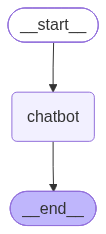

Hello! 👋 It's great to meet you. How can I assist you today?


In [1]:
from typing import Annotated
import os
from dotenv import load_dotenv
load_dotenv()

from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_ollama import ChatOllama
from IPython.display import Image, display
from langgraph.prebuilt import ToolNode, tools_condition

class State(TypedDict):
    messages: Annotated[list, add_messages]

# Standard Quickstart - just getting it running
llm = ChatOllama(model="qwen3.5:4b-mlx", temperature=0.0)

def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

graph_builder = StateGraph(State)
graph_builder.add_node("chatbot", chatbot)
graph_builder.add_edge(START, "chatbot")
graph_builder.add_edge("chatbot", END)

graph = graph_builder.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

# Run quickstart
for event in graph.stream({"messages": [("user", "Hello!")]}):
    for value in event.values():
        print(value["messages"][-1].content)

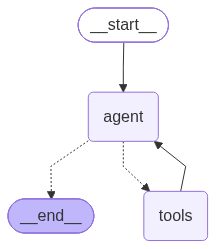

content='' additional_kwargs={} response_metadata={'model': 'qwen3.5:4b-mlx', 'created_at': '2026-08-01T10:50:08.387862Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3621709333, 'load_duration': 50120958, 'prompt_eval_count': 349, 'prompt_eval_duration': 1179262625, 'eval_count': 64, 'eval_duration': 2371866916, 'logprobs': None, 'model_name': 'qwen3.5:4b-mlx', 'model_provider': 'ollama'} id='lc_run--019fbcf2-025b-7083-ad2e-59668611f70f-0' tool_calls=[{'name': 'search_langchain_docs', 'args': {'query': 'LangGraph'}, 'id': 'cf3d1606-2301-46e4-bf6c-8304660e1a2c', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 349, 'output_tokens': 64, 'total_tokens': 413}
content='## Document 1\nSimilarity Score: 0.7965\nSource: https://docs.langchain.com/oss/python/langchain/retrieval\n\nInstructions:\n\n  1. If a user asks a question you\'re unsure about—or one that likely involves API usage,\n     behavior, or configuration—you MUST use the `fetch_documentation

In [2]:
import sys
import os
sys.path.insert(0, os.path.abspath('../src'))
from RAG.agent import search_langchain_docs
from langchain_core.tools import tool

# Mock save_note tool for testing
@tool
def save_note(title: str, content: str) -> str:
    """Save a note about LangChain/LangGraph concepts."""
    return f"Saved note: {title}"

tools = [search_langchain_docs, save_note]
llm_with_tools = llm.bind_tools(tools)

def agent_node(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}

# Build the Graph with tools
tool_node = ToolNode(tools)

app_builder = StateGraph(State)
app_builder.add_node("agent", agent_node)
app_builder.add_node("tools", tool_node)

app_builder.add_edge(START, "agent")
app_builder.add_conditional_edges("agent", tools_condition)
app_builder.add_edge("tools", "agent")

app = app_builder.compile()
display(Image(app.get_graph().draw_mermaid_png()))

# Test the custom RAG tool agent
for event in app.stream({"messages": [("user", "What is LangGraph? Search the docs.")]}):
    for value in event.values():
        print(value["messages"][-1])

In [3]:
1+1

2